In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Set a style for slightly nicer plots
plt.style.use('ggplot')

In [3]:
# 1. Load your raw CSV data
try:
    data = pd.read_csv('comparative_results.csv')

    # 2. Define the metrics you want to average
    metrics_to_average = ['final_confidence', 'word_count', 'processing_time']

    # 3. Group the data by 'blur_radius' and 'system_type', 
    #    then calculate the mean (average) for your metrics.
    summary_table = data.groupby(['blur_radius', 'system_type'])[metrics_to_average].mean().reset_index()

    # 4. Sort the table for better readability
    summary_table = summary_table.sort_values(by=['blur_radius', 'system_type'])

    # 5. Display the final "Central Summary Table"
    print("--- Central Summary Table (Step 1 Complete) ---")
    print(summary_table.to_string(index=False))

except FileNotFoundError:
    print("Error: 'comparative_results.csv' not found.")
    print("Make sure this notebook is in the same folder as your CSV file.")
except Exception as e:
    print(f"An error occurred: {e}")

--- Central Summary Table (Step 1 Complete) ---
 blur_radius system_type  final_confidence  word_count  processing_time
           0         MAS               9.0        41.0       110.333959
           0         SAS               6.5        16.5        10.205182
           2         MAS               9.0        36.5       212.977334
           2         SAS               7.5        15.0         9.053934
           5         MAS               9.0        36.0       291.336642
           5         SAS               6.0        21.0         9.075789
          10         MAS               9.0        36.0       644.188108
          10         SAS               4.5        21.0         7.645151
          15         MAS               9.0        36.0       407.044425
          15         SAS               5.0        18.5         7.070502
          20         MAS               9.0        36.0       727.086842
          20         SAS               4.5        14.5         6.589903


In [4]:
# Separate the data for SAS and MAS for easy plotting
sas_data = summary_table[summary_table['system_type'] == 'SAS']
mas_data = summary_table[summary_table['system_type'] == 'MAS']

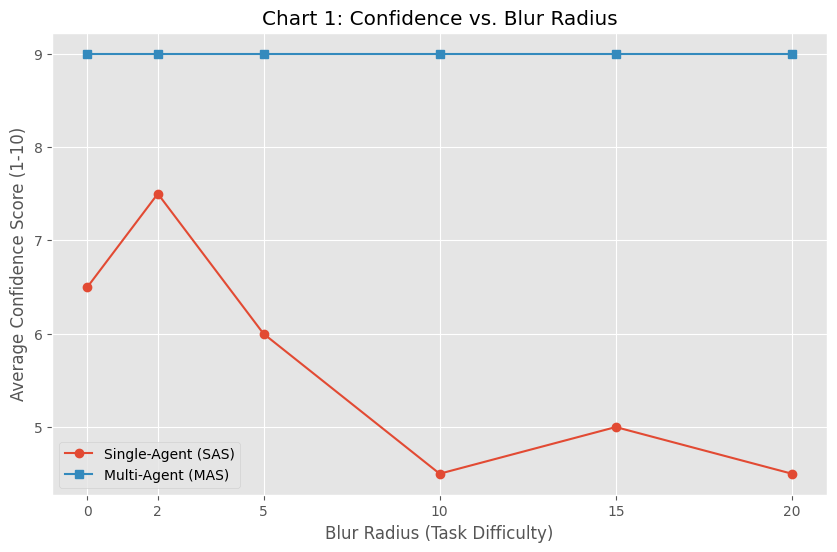

In [6]:
# Cell 4 (Corrected)
plt.figure(figsize=(10, 6))

# Plot the two lines
plt.plot(sas_data['blur_radius'], sas_data['final_confidence'], label='Single-Agent (SAS)', marker='o')
plt.plot(mas_data['blur_radius'], mas_data['final_confidence'], label='Multi-Agent (MAS)', marker='s')

# Add labels and title as planned (with [cite] tags removed)
plt.title('Chart 1: Confidence vs. Blur Radius')
plt.xlabel('Blur Radius (Task Difficulty)')
plt.ylabel('Average Confidence Score (1-10)')
plt.xticks(sas_data['blur_radius'])  # Ensure all blur levels are shown
plt.legend()
plt.grid(True)
plt.show()

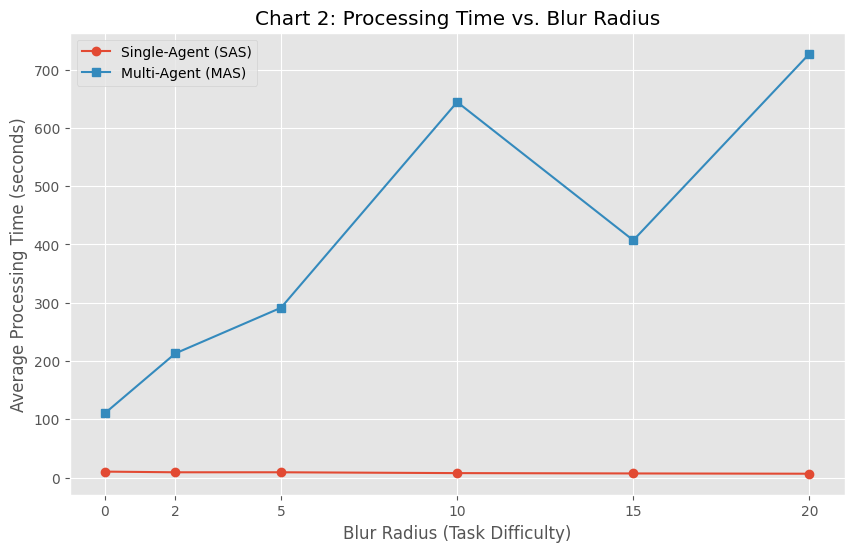

In [8]:
plt.figure(figsize=(10, 6))

# Plot the two lines
plt.plot(sas_data['blur_radius'], sas_data['processing_time'], label='Single-Agent (SAS)', marker='o')
plt.plot(mas_data['blur_radius'], mas_data['processing_time'], label='Multi-Agent (MAS)', marker='s')

# Add labels and title as planned
plt.title('Chart 2: Processing Time vs. Blur Radius')
plt.xlabel('Blur Radius (Task Difficulty)')
plt.ylabel('Average Processing Time (seconds)')
plt.xticks(sas_data['blur_radius'])
plt.legend()
plt.grid(True)
plt.show()

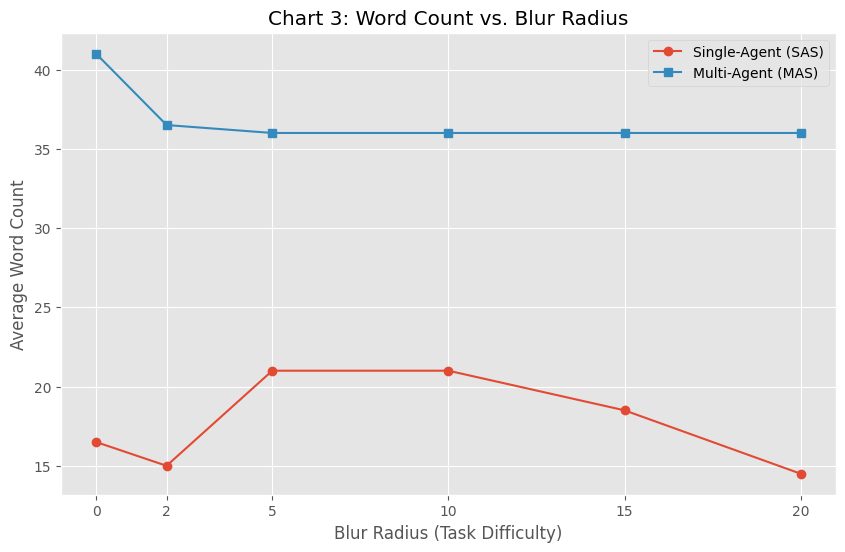

In [10]:
plt.figure(figsize=(10, 6))

# Plot the two lines
plt.plot(sas_data['blur_radius'], sas_data['word_count'], label='Single-Agent (SAS)', marker='o')
plt.plot(mas_data['blur_radius'], mas_data['word_count'], label='Multi-Agent (MAS)', marker='s')

# Add labels and title as planned
plt.title('Chart 3: Word Count vs. Blur Radius')
plt.xlabel('Blur Radius (Task Difficulty)')
plt.ylabel('Average Word Count')
plt.xticks(sas_data['blur_radius'])
plt.legend()
plt.grid(True)
plt.show()